# Required Packages, Modules and Utilities

In [1]:
# Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models and Utilities
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


%matplotlib inline
import warnings
warnings.simplefilter("ignore")

# Data Ingestion

In [2]:
# Import csv files to DataFrame format
uk_data = pd.read_csv("uk_road_accident.csv")

In [3]:
# Function to get data summary
def get_data_profile(df):
    print('-' * 100)
    print(f'No. of Rows: {df.shape[0]}        No. of Columns: {df.shape[1]}')
    print('-' * 100)

    data_profile = pd.DataFrame({
        'DataType': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Unique Values': df.nunique()
    })

    print(data_profile)
    print('-' * 100)

In [4]:
# First view of dataset
get_data_profile(uk_data)

----------------------------------------------------------------------------------------------------
No. of Rows: 1048575        No. of Columns: 34
----------------------------------------------------------------------------------------------------
                                            DataType  Missing Values  \
Accident_Index                                object               0   
1st_Road_Class                                object          305589   
1st_Road_Number                              float64               2   
2nd_Road_Class                                object          439824   
2nd_Road_Number                              float64           10803   
Accident_Severity                             object               0   
Carriageway_Hazards                           object              29   
Date                                          object               0   
Day_of_Week                                   object               0   
Did_Police_Officer_Attend_Scene

# Data Cleaning

In [5]:
# Show first five rows
uk_data.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,None,04/01/2005,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,None,30,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,None,05/01/2005,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,None,30,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,None,06/01/2005,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,None,30,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,None,07/01/2005,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,None,30,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,NaN,0.0,NaN,0.0,Slight,None,10/01/2005,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,None,30,21:13,Urban,Fine no high winds,2005,No


In [6]:
# Get columns
uk_data.columns

Index(['Accident_Index', '1st_Road_Class', '1st_Road_Number', '2nd_Road_Class',
       '2nd_Road_Number', 'Accident_Severity', 'Carriageway_Hazards', 'Date',
       'Day_of_Week', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'Junction_Control', 'Junction_Detail', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'LSOA_of_Accident_Location', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Special_Conditions_at_Site',
       'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Year', 'InScotland'],
      dtype='object')

In [7]:
# Check for duplicates across all columns
print(uk_data[uk_data.duplicated()])

# Remove duplicates from daaset
uk_data.drop_duplicates(inplace=True)

       Accident_Index 1st_Road_Class  1st_Road_Number 2nd_Road_Class  \
58964     2.00512E+12            NaN              0.0              A   
148119    2.00546E+12            NaN              0.0            NaN   
151435    2.00546E+12              A             20.0            NaN   
663493    2.00833E+12              A            606.0            NaN   
732740    2.00895E+12              A              1.0            NaN   
791085    2.00913E+12              A            672.0            NaN   

        2nd_Road_Number Accident_Severity Carriageway_Hazards        Date  \
58964              64.0            Slight                None  04/02/2005   
148119              0.0            Slight                None  18/05/2005   
151435              0.0            Slight                None  19/05/2005   
663493              0.0            Slight                None  27/12/2008   
732740              0.0            Slight                None  05/04/2008   
791085              0.0          

In [8]:
# Show the unique values of each column in the dataset

for column in uk_data.columns:
    unique_values = uk_data[column].unique()
    print(f"Unique values in {column} ({len(unique_values)}): {unique_values}")

Unique values in Accident_Index (671340): ['200501BS00001' '200501BS00002' '200501BS00003' ... '201091NM01935'
 '201091NM01964' '201091NM02142']
Unique values in 1st_Road_Class (6): ['A' 'B' 'C' nan 'Motorway' 'A(M)']
Unique values in 1st_Road_Number (6553): [3218.  450.    0. ... 4372. 9064. 9070.]
Unique values in 2nd_Road_Class (7): [nan 'C' 'Unclassified' 'B' 'A' 'Motorway' 'A(M)']
Unique values in 2nd_Road_Number (6940): [   0.  304.  325. ... 7888. 4842. 9165.]
Unique values in Accident_Severity (3): ['Serious' 'Slight' 'Fatal']
Unique values in Carriageway_Hazards (7): ['None' 'Other object on road' 'Pedestrian in carriageway - not injured'
 'Vehicle load on road' 'Previous accident'
 'Any animal in carriageway (except ridden horse)' nan]
Unique values in Date (2191): ['04/01/2005' '05/01/2005' '06/01/2005' ... '26/12/2010' '25/07/2010'
 '25/12/2010']
Unique values in Day_of_Week (7): ['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Monday' 'Saturday' 'Sunday']
Unique values in Did_P

Unique values in Longitude (774516): [-0.19117  -0.211708 -0.206458 ... -3.862727 -3.823997 -3.895673]
Unique values in LSOA_of_Accident_Location (34227): ['E01002849' 'E01002909' 'E01002857' ... 'W01001488' 'W01001386'
 'W01001123']
Unique values in Number_of_Casualties (41): [ 1  2  5  4  3  8  7  6 10  9 23 17 13 11 19 15 16 12 14 18 20 29 21 35
 22 26 45 41 36 40 25 28 42 68 27 32 62 47 48 24 43]
Unique values in Number_of_Vehicles (23): [ 1  2  4  3  5  6  8  7 13 10 11 18  9 20 17 15 12 14 22 16 28 32 19]
Unique values in Pedestrian_Crossing-Human_Control (4): [ 0.  2.  1. nan]
Unique values in Pedestrian_Crossing-Physical_Facilities (7): [ 1.  5.  0.  8.  4.  7. nan]
Unique values in Police_Force (51): ['Metropolitan Police' 'City of London' 'Cumbria' 'Lancashire'
 'Merseyside' 'Greater Manchester' 'Cheshire' 'Northumbria' 'Durham'
 'North Yorkshire' 'West Yorkshire' 'South Yorkshire' 'Humberside'
 'Cleveland' 'West Midlands' 'Staffordshire' 'West Mercia' 'Warwickshire'
 'Derbys

In [9]:
# Remove columns of lesser importance in predicting accident severity
cols_to_remove = [
    'Accident_Index', '1st_Road_Class', '1st_Road_Number', '2nd_Road_Class', '2nd_Road_Number',
    'Carriageway_Hazards', 'Latitude', 'Longitude', 'Police_Force', 'LSOA_of_Accident_Location', 
    'Local_Authority_(District)', 'Local_Authority_(Highway)', 'Did_Police_Officer_Attend_Scene_of_Accident',
    'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Special_Conditions_at_Site', 'InScotland',
    'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Year', 'Date'
]

uk_data.drop(columns=cols_to_remove, inplace=True)
uk_data.columns

Index(['Accident_Severity', 'Day_of_Week', 'Junction_Control',
       'Junction_Detail', 'Light_Conditions', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Road_Surface_Conditions', 'Road_Type',
       'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions'],
      dtype='object')

In [10]:
# Number of missing values after removal of irrelevant columns
print("Count of Missing Values: ", uk_data.isnull().sum().sum())
print(uk_data.isnull().sum().sort_values(ascending=False))

# Drop all NaN/Null values
uk_data.dropna(inplace=True)

Count of Missing Values:  32116
Weather_Conditions         21392
Road_Type                   7266
Light_Conditions            2084
Road_Surface_Conditions     1189
Time                         100
Urban_or_Rural_Area           85
Accident_Severity              0
Day_of_Week                    0
Junction_Control               0
Junction_Detail                0
Number_of_Casualties           0
Number_of_Vehicles             0
Speed_limit                    0
dtype: int64


In [11]:
# Convert Time column to a datetime format
uk_data['Time'] = pd.to_datetime(uk_data['Time'])

# Extract Hour of Accident Occurrence
uk_data['Hour'] = uk_data['Time'].dt.hour


uk_data.drop(columns=['Time'], inplace=True)

In [12]:
# Uniformity of Column values

uk_data['Junction_Control'] = uk_data['Junction_Control'].replace('Auto traffic sigl', 'Auto traffic signal')

In [13]:
# # Count occurrences of 'Data missing or out of range' across all columns
print((uk_data == 'Data missing or out of range').sum())

# Replace all instances of 'Data missing or out of range' with 'Unknown' across all columns
uk_data = uk_data.replace('Data missing or out of range', 'Unknown')

Accident_Severity               0
Day_of_Week                     0
Junction_Control           342932
Junction_Detail                 4
Light_Conditions                0
Number_of_Casualties            0
Number_of_Vehicles              0
Road_Surface_Conditions         0
Road_Type                       0
Speed_limit                     0
Urban_or_Rural_Area             0
Weather_Conditions              0
Hour                            0
dtype: int64


In [14]:
# Light Conditions: Daylight & Darkness

light_con_mapping = {'Darkness - lights lit': 'Darkness',
                     'Darkness - lighting unknown': 'Darkness',
                     'Darkness - no lighting': 'Darkness',
                     'Darkness - lights unlit': 'Darkness'}

uk_data['Light_Conditions'] = uk_data['Light_Conditions'].replace(light_con_mapping)

uk_data['Light_Conditions'].value_counts()

Daylight    744134
Darkness    274633
Name: Light_Conditions, dtype: int64

In [15]:
# Show the unique values of each column in the dataset
# After data cleaning process

for column in uk_data.columns:
    unique_values = uk_data[column].unique()
    print(f"Unique values in {column} ({len(unique_values)}): {unique_values}")
    

# Save cleaned data
uk_data.to_csv("uk_data_cleaned.csv", index=False)

Unique values in Accident_Severity (3): ['Slight' 'Serious' 'Fatal']
Unique values in Day_of_Week (7): ['Wednesday' 'Thursday' 'Monday' 'Saturday' 'Sunday' 'Tuesday' 'Friday']
Unique values in Junction_Control (6): ['Auto traffic signal' 'Unknown' 'Give way or uncontrolled' 'Stop sign'
 'Authorised person' 'Not at junction or within 20 metres']
Unique values in Junction_Detail (10): ['Crossroads' 'Not at junction or within 20 metres'
 'T or staggered junction' 'Mini-roundabout' 'Other junction'
 'More than 4 arms (not roundabout)' 'Roundabout'
 'Private drive or entrance' 'Slip road' 'Unknown']
Unique values in Light_Conditions (2): ['Darkness' 'Daylight']
Unique values in Number_of_Casualties (41): [ 1  2  4  3  5  7  6 10  9  8 23 17 13 11 19 15 16 12 14 18 20 29 21 35
 22 26 45 41 36 40 25 28 42 68 27 32 62 47 48 24 43]
Unique values in Number_of_Vehicles (23): [ 1  2  4  3  5  6  8  7 13 10 11 18  9 20 17 15 12 14 22 16 28 32 19]
Unique values in Road_Surface_Conditions (5): ['Dry'

# Data Analysis and Visualization

In [16]:
# Get a view of the cleaned dataset
get_data_profile(uk_data)

----------------------------------------------------------------------------------------------------
No. of Rows: 1018767        No. of Columns: 13
----------------------------------------------------------------------------------------------------
                        DataType  Missing Values  Unique Values
Accident_Severity         object               0              3
Day_of_Week               object               0              7
Junction_Control          object               0              6
Junction_Detail           object               0             10
Light_Conditions          object               0              2
Number_of_Casualties       int64               0             41
Number_of_Vehicles         int64               0             23
Road_Surface_Conditions   object               0              5
Road_Type                 object               0              5
Speed_limit                int64               0              8
Urban_or_Rural_Area       object               

In [17]:
# Summary of dataset
uk_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1018767 entries, 1 to 1048574
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   Accident_Severity        1018767 non-null  object
 1   Day_of_Week              1018767 non-null  object
 2   Junction_Control         1018767 non-null  object
 3   Junction_Detail          1018767 non-null  object
 4   Light_Conditions         1018767 non-null  object
 5   Number_of_Casualties     1018767 non-null  int64 
 6   Number_of_Vehicles       1018767 non-null  int64 
 7   Road_Surface_Conditions  1018767 non-null  object
 8   Road_Type                1018767 non-null  object
 9   Speed_limit              1018767 non-null  int64 
 10  Urban_or_Rural_Area      1018767 non-null  object
 11  Weather_Conditions       1018767 non-null  object
 12  Hour                     1018767 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 108.8+ MB


### *Time-based Analysis*

17    89134
16    81720
15    78347
8     74147
18    69550
Name: Hour, dtype: int64


<Axes: xlabel='Hour', ylabel='count'>

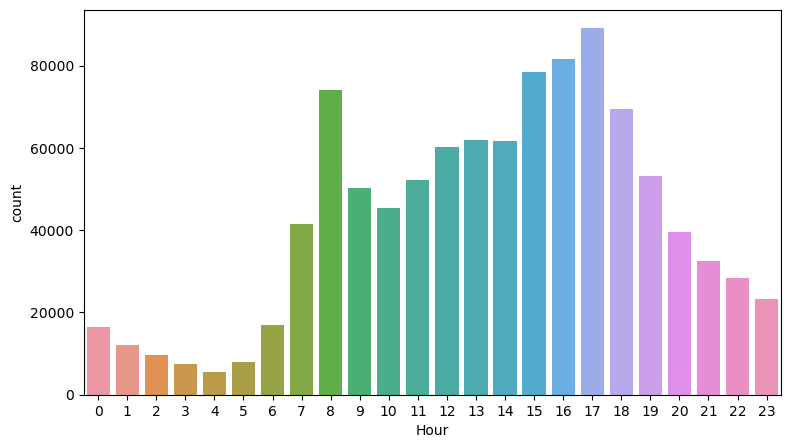

In [18]:
# Display the number of accidents by hour, showing the top 5 hours with the most accidents
print(uk_data['Hour'].value_counts().head())

plt.figure(figsize=(9, 5))
sns.countplot(data=uk_data, x='Hour')

Friday       166938
Wednesday    153497
Tuesday      151611
Thursday     151239
Monday       144234
Saturday     138277
Sunday       112971
Name: Day_of_Week, dtype: int64


<Axes: xlabel='Day_of_Week', ylabel='count'>

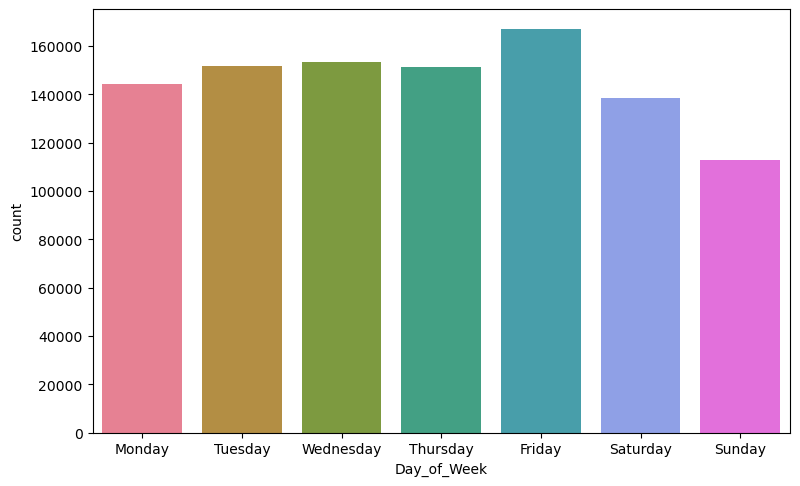

In [19]:
# Count of accidents per day of the week
print(uk_data['Day_of_Week'].value_counts())

day_of_the_week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(9, 5.5))
sns.countplot(data=uk_data, x='Day_of_Week', palette='husl', order=day_of_the_week)

### *Accident Severity and other Variables*

Accident_Severity  Junction_Control                   
Fatal              Unknown                                  7485
                   Give way or uncontrolled                 4402
                   Not at junction or within 20 metres      1646
                   Auto traffic signal                       648
                   Stop sign                                  61
                   Authorised person                           7
Serious            Give way or uncontrolled                59164
                   Unknown                                 53252
                   Not at junction or within 20 metres     11470
                   Auto traffic signal                     10676
                   Stop sign                                 710
                   Authorised person                         165
Slight             Give way or uncontrolled               425878
                   Unknown                                282195
                   Auto traffic sig

<Axes: xlabel='Accident_Severity', ylabel='count'>

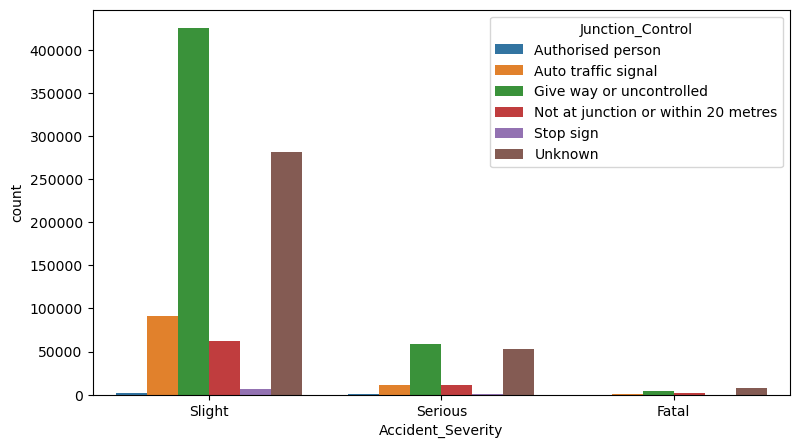

In [20]:
# Distribution of junction controls across accident severity categories
print(uk_data.groupby('Accident_Severity')['Junction_Control'].value_counts(), '\n')

junc_ctrl = sorted(uk_data['Junction_Control'].unique())

plt.figure(figsize=(9, 5))
sns.countplot(data=uk_data, x='Accident_Severity', hue='Junction_Control', hue_order=junc_ctrl)

Accident_Severity
Fatal      28
Serious    22
Slight     32
Name: Number_of_Vehicles, dtype: int64


<Axes: xlabel='Accident_Severity', ylabel='Number_of_Vehicles'>

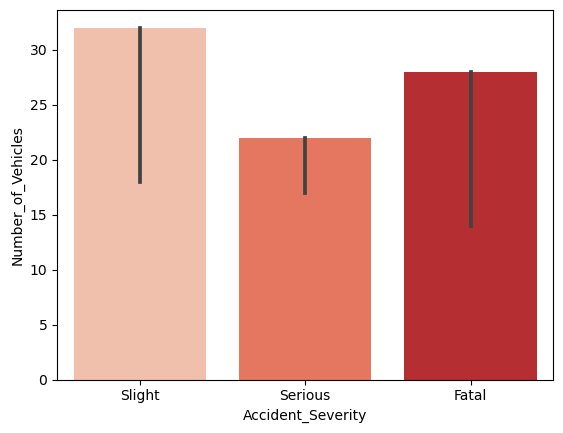

In [21]:
# Maximum number of vehicles involved for each accident severity category
print(uk_data.groupby('Accident_Severity')['Number_of_Vehicles'].max())

sns.barplot(data=uk_data, x='Accident_Severity', y='Number_of_Vehicles', estimator='max', palette='Reds')

Accident_Severity
Fatal      68
Serious    45
Slight     47
Name: Number_of_Casualties, dtype: int64


<Axes: xlabel='Accident_Severity', ylabel='Number_of_Casualties'>

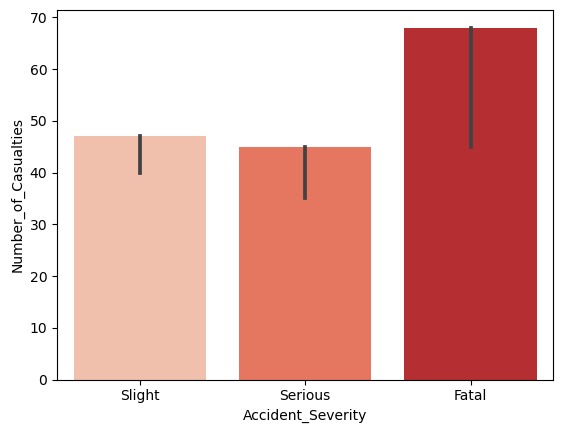

In [22]:
# Maximum number of casualties for each accident severity category
print(uk_data.groupby('Accident_Severity')['Number_of_Casualties'].max())

sns.barplot(data=uk_data, x='Accident_Severity', y='Number_of_Casualties', estimator='max', palette='Reds')

Accident_Severity  Light_Conditions
Fatal              Daylight            0.581234
                   Darkness            0.418766
Serious            Daylight            0.681195
                   Darkness            0.318805
Slight             Daylight            0.740544
                   Darkness            0.259456
Name: Light_Conditions, dtype: float64


Light_Conditions    Daylight   Darkness
Accident_Severity                      
Slight             74.054432  25.945568
Serious            68.119495  31.880505
Fatal              58.123377  41.876623




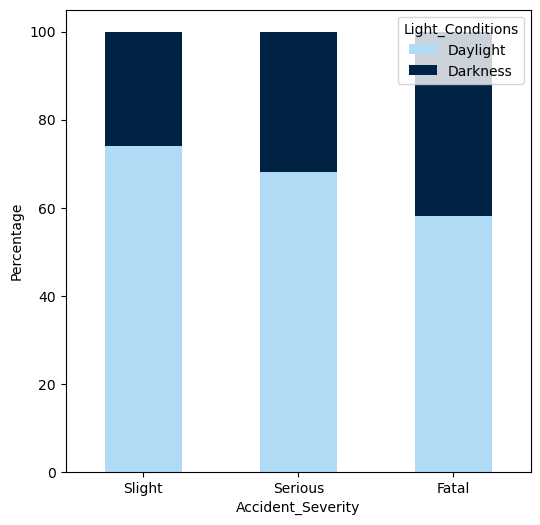

In [23]:
# Percentage of light conditions across accident severity categories

severity_wrt_dayandnight = uk_data.groupby('Accident_Severity')['Light_Conditions'].value_counts(normalize=True)
print(severity_wrt_dayandnight)
print('\n')

severity_wrt_dayandnight_percent = (severity_wrt_dayandnight.unstack() * 100)[['Daylight', 'Darkness']]
severity_wrt_dayandnight_percent = severity_wrt_dayandnight_percent.sort_index(ascending=False)
print(severity_wrt_dayandnight_percent)
print('\n')

fig, ax = plt.subplots(figsize=(6, 6))    # for a larger figure object and axis
severity_wrt_dayandnight_percent.plot(kind='bar', stacked=True, color=['#AFDBF5', '#002244'], rot=0, ax=ax)
ax.set_ylabel('Percentage')
plt.show()

Accident_Severity  Road_Type         
Fatal              Single carriageway     10803
                   Dual carriageway        2968
                   Roundabout               234
                   One way street           153
                   Slip road                 91
Serious            Single carriageway    107939
                   Dual carriageway       18430
                   Roundabout              5525
                   One way street          2611
                   Slip road                932
Slight             Single carriageway    645262
                   Dual carriageway      134138
                   Roundabout             61248
                   One way street         18679
                   Slip road               9754
Name: Road_Type, dtype: int64


<Axes: xlabel='Accident_Severity', ylabel='count'>

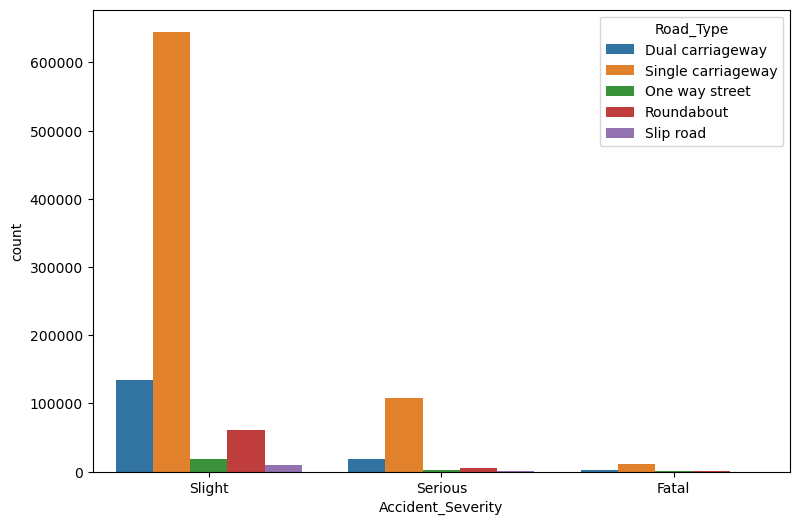

In [24]:
# Distribution of different road types across accident severity categories
print(uk_data.groupby('Accident_Severity')['Road_Type'].value_counts())

plt.figure(figsize=(9, 6))
sns.countplot(data=uk_data, x='Accident_Severity', hue='Road_Type')

Accident_Severity
Fatal      49.086252
Serious    41.058536
Slight     39.146017
Name: Speed_limit, dtype: float64


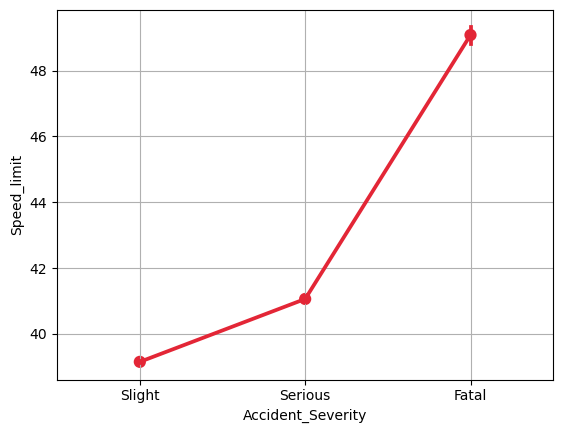

In [25]:
# Average speed limit for each accident severity category
print(uk_data.groupby('Accident_Severity')['Speed_limit'].mean())

sns.pointplot(data=uk_data, x='Accident_Severity', y='Speed_limit', color='#E32636')
plt.grid()

Accident_Severity  Urban_or_Rural_Area
Fatal              Rural                    9219
                   Urban                    5030
Serious            Urban                   77621
                   Rural                   57808
                   Unallocated                 8
Slight             Urban                  563772
                   Rural                  305262
                   Unallocated                47
Name: Urban_or_Rural_Area, dtype: int64 



<Axes: xlabel='Accident_Severity', ylabel='count'>

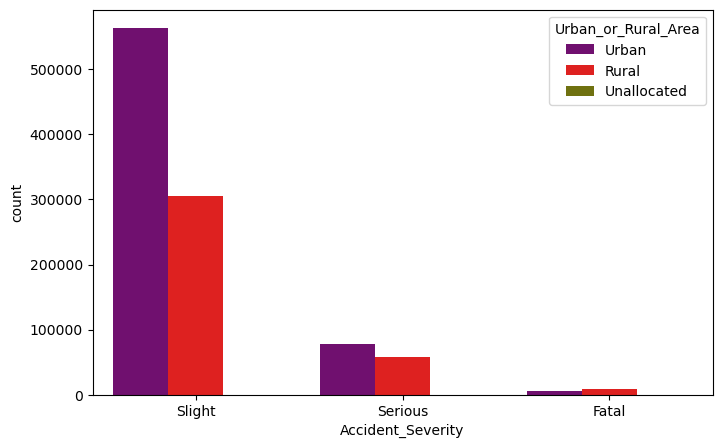

In [26]:
# Distribution of accident severity categories across urban and rural areas
print(uk_data.groupby('Accident_Severity')['Urban_or_Rural_Area'].value_counts(), '\n')

plt.figure(figsize=(8, 5))
sns.countplot(data=uk_data, x='Accident_Severity', hue='Urban_or_Rural_Area', palette='brg')

# Feature Engineering

In [27]:
# Get datatypes of dataset columns
uk_data.dtypes

Accident_Severity          object
Day_of_Week                object
Junction_Control           object
Junction_Detail            object
Light_Conditions           object
Number_of_Casualties        int64
Number_of_Vehicles          int64
Road_Surface_Conditions    object
Road_Type                  object
Speed_limit                 int64
Urban_or_Rural_Area        object
Weather_Conditions         object
Hour                        int64
dtype: object

In [28]:
# Numeric features
numeric_data = uk_data.select_dtypes(include=['int'])
numeric_cols = numeric_data.columns
print(numeric_cols)

Index(['Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit', 'Hour'], dtype='object')


In [29]:
# Encode categorical features

non_numeric_data = uk_data.select_dtypes(include=['object'])
non_numeric_cols = non_numeric_data.columns.drop(['Accident_Severity'])

print(non_numeric_cols, '\n')

non_numeric_data = non_numeric_data[non_numeric_cols]
print(non_numeric_data.iloc[:2], '\n\n')

label_encoder = LabelEncoder()

for col in non_numeric_cols:
    non_numeric_data[col] = label_encoder.fit_transform(non_numeric_data[col])

print(non_numeric_data.iloc[:2])

Index(['Day_of_Week', 'Junction_Control', 'Junction_Detail',
       'Light_Conditions', 'Road_Surface_Conditions', 'Road_Type',
       'Urban_or_Rural_Area', 'Weather_Conditions'],
      dtype='object') 

  Day_of_Week     Junction_Control                      Junction_Detail  \
1   Wednesday  Auto traffic signal                           Crossroads   
2    Thursday              Unknown  Not at junction or within 20 metres   

  Light_Conditions Road_Surface_Conditions           Road_Type  \
1         Darkness                     Dry    Dual carriageway   
2         Darkness                     Dry  Single carriageway   

  Urban_or_Rural_Area  Weather_Conditions  
1               Urban  Fine no high winds  
2               Urban  Fine no high winds   


   Day_of_Week  Junction_Control  Junction_Detail  Light_Conditions  \
1            6                 1                0                 0   
2            4                 5                3                 0   

   Road_Surface_Condi

In [30]:
# Combine relevant features
features = non_numeric_data.join(uk_data[numeric_cols])
features.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1018767 entries, 1 to 1048574
Data columns (total 12 columns):
 #   Column                   Non-Null Count    Dtype
---  ------                   --------------    -----
 0   Day_of_Week              1018767 non-null  int32
 1   Junction_Control         1018767 non-null  int32
 2   Junction_Detail          1018767 non-null  int32
 3   Light_Conditions         1018767 non-null  int32
 4   Road_Surface_Conditions  1018767 non-null  int32
 5   Road_Type                1018767 non-null  int32
 6   Urban_or_Rural_Area      1018767 non-null  int32
 7   Weather_Conditions       1018767 non-null  int32
 8   Number_of_Casualties     1018767 non-null  int64
 9   Number_of_Vehicles       1018767 non-null  int64
 10  Speed_limit              1018767 non-null  int64
 11  Hour                     1018767 non-null  int64
dtypes: int32(8), int64(4)
memory usage: 102.2 MB


In [31]:
# Verify that the label encoder preserves the count of unique values within encoded categorical columns

basic_data = uk_data[features.columns]
features.columns.nunique() == basic_data.columns.nunique()

True

In [32]:
# Encode Categorical Target variable with unique numbers
map_label = lambda a: 1 if a == 'Slight' else 2 if a == 'Serious' else 3
uk_data['Severity'] = uk_data['Accident_Severity'].map(map_label)

uk_data['Severity'].value_counts()

1    869081
2    135437
3     14249
Name: Severity, dtype: int64

Slight     869081
Serious    135437
Fatal       14249
Name: Accident_Severity, dtype: int64


<Axes: xlabel='Accident_Severity', ylabel='count'>

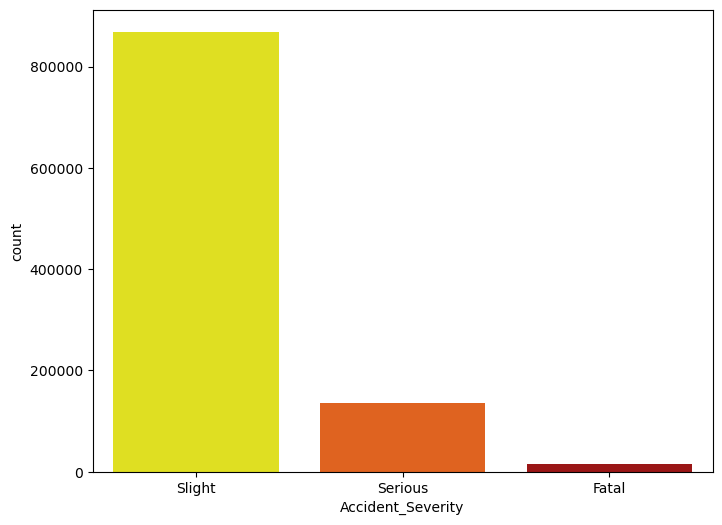

In [33]:
# Count of the unique values of the target variable
print(uk_data['Accident_Severity'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=uk_data, x='Accident_Severity', palette='hot_r')

In [34]:
# Training Features
X = features.values
print(X.shape)

(1018767, 12)


In [35]:
# Target variable
y = uk_data['Severity'].values
print(y.shape)

(1018767,)


# Model Training and Evaluation

In [36]:
severity_order = uk_data['Accident_Severity'].unique()
print(severity_order)

['Slight' 'Serious' 'Fatal']


In [37]:
# Set seed for reproducibility
SEED = 21

# the models
models = [DecisionTreeClassifier(random_state=SEED),
          KNeighborsClassifier(),
          LogisticRegression(random_state=SEED, max_iter=300),
          LinearSVC(random_state=SEED)]

In [38]:
# Split data into 70% training set and 30% test set
# X: features; y: target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

print(X_train.shape, '\n', X_test.shape)

(713136, 12) 
 (305631, 12)



Predictive Results for DecisionTreeClassifier: 

Accuracy: 0.82

              precision    recall  f1-score   support

      Slight       0.86      0.95      0.90    260725
     Serious       0.19      0.07      0.10     40631
       Fatal       0.06      0.03      0.04      4275

    accuracy                           0.82    305631
   macro avg       0.37      0.35      0.35    305631
weighted avg       0.76      0.82      0.78    305631

[[247618  11709   1398]
 [ 37308   2864    459]
 [  3649    511    115]]


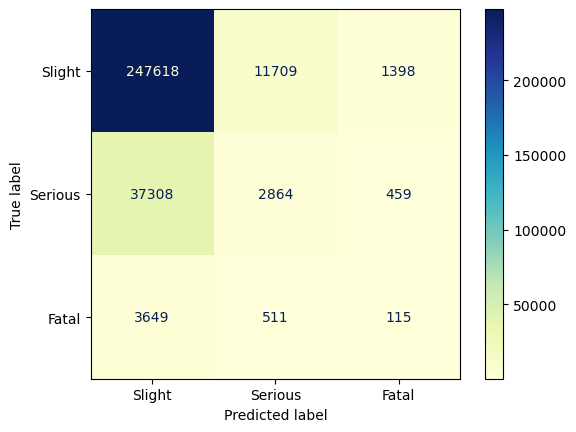


Predictive Results for KNeighborsClassifier: 

Accuracy: 0.839

              precision    recall  f1-score   support

      Slight       0.86      0.98      0.91    260725
     Serious       0.22      0.05      0.08     40631
       Fatal       0.10      0.00      0.01      4275

    accuracy                           0.84    305631
   macro avg       0.39      0.34      0.33    305631
weighted avg       0.76      0.84      0.79    305631

[[254462   6204     59]
 [ 38722   1872     37]
 [  3928    336     11]]


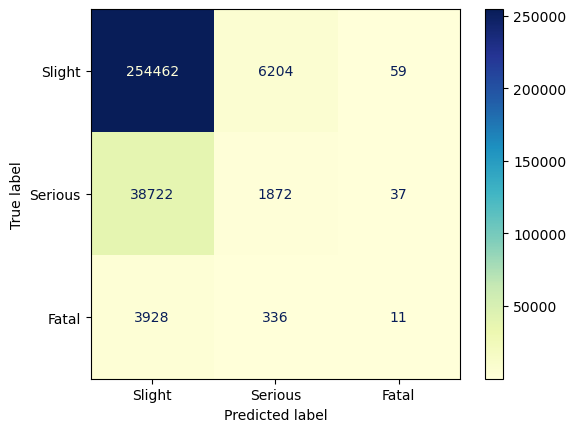


Predictive Results for LogisticRegression: 

Accuracy: 0.853

              precision    recall  f1-score   support

      Slight       0.85      1.00      0.92    260725
     Serious       0.38      0.00      0.00     40631
       Fatal       0.11      0.00      0.00      4275

    accuracy                           0.85    305631
   macro avg       0.45      0.33      0.31    305631
weighted avg       0.78      0.85      0.79    305631

[[260609    102     14]
 [ 40535     79     17]
 [  4242     29      4]]


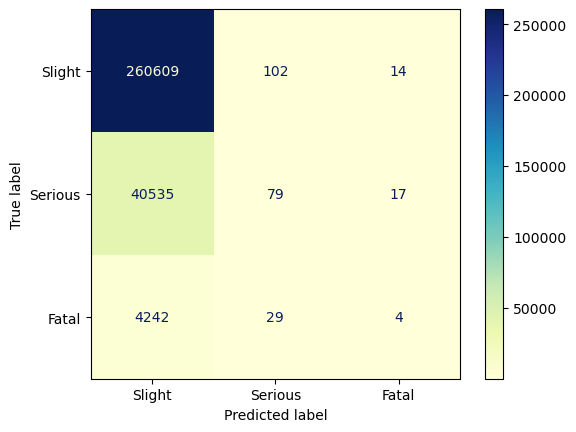


Predictive Results for LinearSVC: 

Accuracy: 0.65

              precision    recall  f1-score   support

      Slight       0.87      0.70      0.78    260725
     Serious       0.16      0.39      0.23     40631
       Fatal       0.00      0.00      0.00      4275

    accuracy                           0.65    305631
   macro avg       0.35      0.36      0.34    305631
weighted avg       0.77      0.65      0.69    305631

[[183006  77719      0]
 [ 24828  15803      0]
 [  1457   2818      0]]


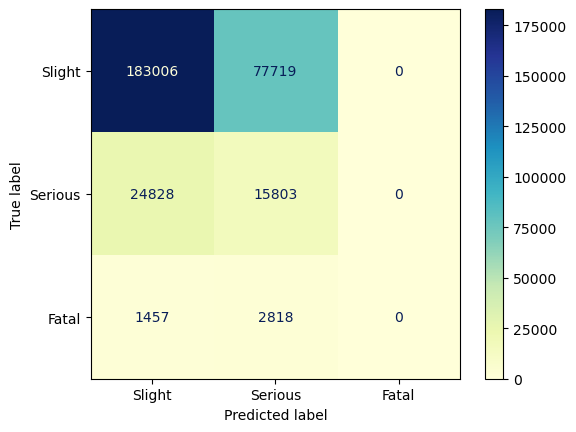

In [39]:
# Lists for evaluation results
model_list = []
accuracy_list = []

for model in models:
    model_name = model.__class__.__name__
    model.fit(X_train, y_train)
    model_pred = model.predict(X_test)

    # Mapping of scorer name to scorer function
    accuracy = round(accuracy_score(y_test, model_pred), 3)

    # Append results to corresponding lists
    model_list.append(model_name)
    accuracy_list.append(accuracy)

    print(f"\nPredictive Results for {model_name}: ")

    print(f"\nAccuracy: {accuracy}\n")

    print(classification_report(y_test, model_pred, target_names=severity_order))
    
    cm = confusion_matrix(y_test, model_pred)
    print(cm)
        
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=severity_order)
    cm_display.plot(cmap='YlGnBu')
    plt.show()

    print("=" * 100)

In [40]:
# Convert lists to a single DataFrame
dict_of_lists = {"Model": model_list, "Accuracy": accuracy_list}
accuracy_results = pd.DataFrame(dict_of_lists)

accuracy_results.sort_values(by='Accuracy', ascending=False, inplace=True)
accuracy_results

,Model,Accuracy
2,LogisticRegression,0.853
1,KNeighborsClassifier,0.839
0,DecisionTreeClassifier,0.820
3,LinearSVC,0.650


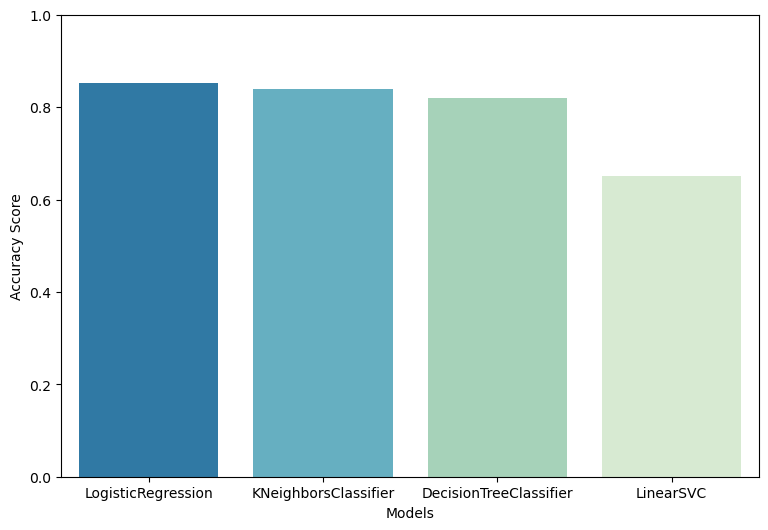

In [41]:
plt.figure(figsize=(9, 6))
sns.barplot(data=accuracy_results, x='Model', y='Accuracy', palette='GnBu_r')

plt.xlabel("Models")
plt.ylabel("Accuracy Score")

plt.yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.show()